In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import scatter_matrix
from pathlib import Path

In [4]:
DATA_PATH = "../data/googleplaystore.csv"
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

In [5]:
def clean_size(value):
    value = str(value)
    if "M" in value:
        return float(value.replace("M", ""))
    if "k" in value:
        return float(value.replace("k", "")) / 1024
    return np.nan

In [6]:
df = pd.read_csv(DATA_PATH)

df = df[df["Rating"] <= 5].copy()
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = (
    df["Installs"].astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Size"] = df["Size"].apply(clean_size)

data = df[["Rating", "Reviews", "Size", "Installs", "Price"]].dropna()

data["log_Reviews"] = np.log1p(data["Reviews"])
data["log_Installs"] = np.log1p(data["Installs"])
data["log_Price"] = np.log1p(data["Price"])

data.head()

,Rating,Reviews,Size,Installs,Price,log_Reviews,log_Installs,log_Price
0,4.1,159,19.0,10000,0.0,5.075174,9.210440,0.0
1,3.9,967,14.0,500000,0.0,6.875232,13.122365,0.0
2,4.7,87510,8.7,5000000,0.0,11.379520,15.424949,0.0
3,4.5,215644,25.0,50000000,0.0,12.281389,17.727534,0.0
4,4.3,967,2.8,100000,0.0,6.875232,11.512935,0.0


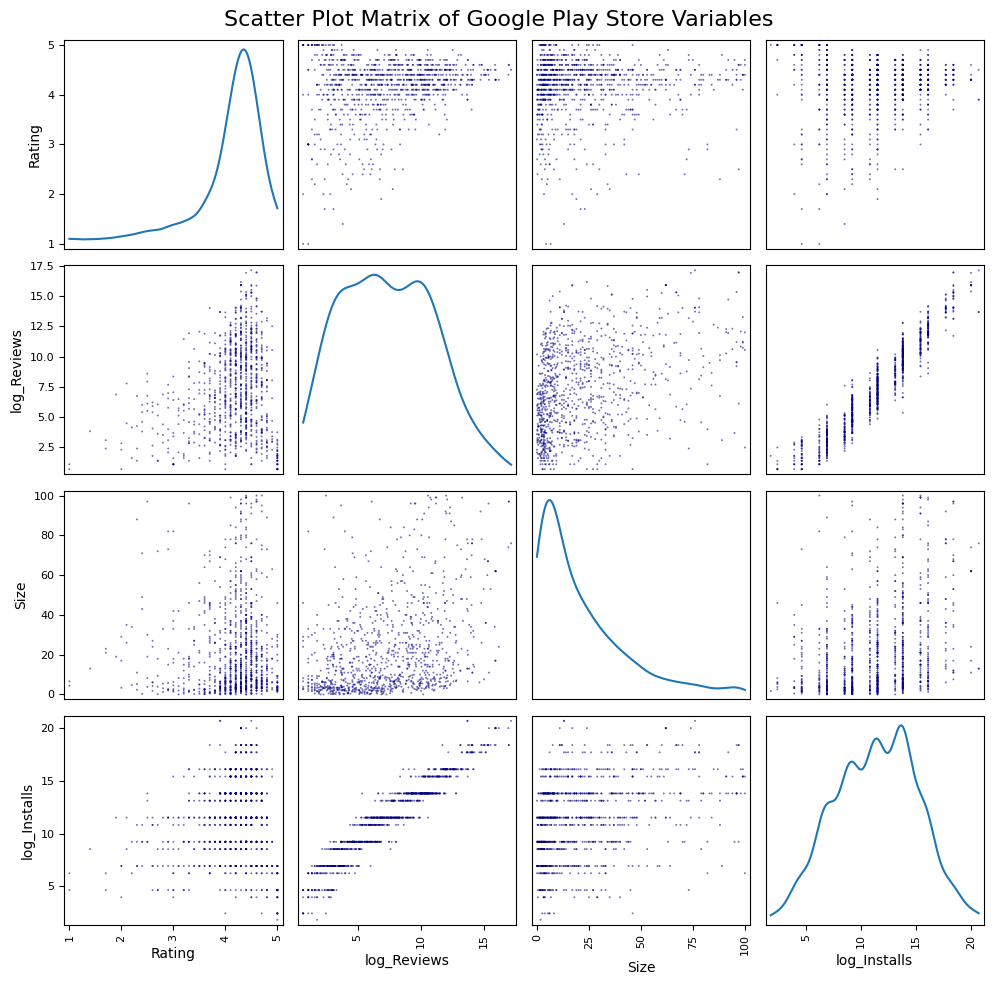

In [7]:
plot_data = data[["Rating", "log_Reviews", "Size", "log_Installs"]].sample(1000, random_state=42)

scatter_matrix(
    plot_data,
    figsize=(10, 10),
    diagonal="kde",
    alpha=0.55,
    s=8,
    color="navy"
)

plt.suptitle("Scatter Plot Matrix of Google Play Store Variables", fontsize=16)
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_matrix_googleplay.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "scatter_matrix_googleplay.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
y = data["Rating"]
x = data[["log_Reviews", "Size", "log_Installs", "log_Price"]]
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     253.6
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          4.93e-205
Time:                        11:53:08   Log-Likelihood:                -5792.2
No. Observations:                7729   AIC:                         1.159e+04
Df Residuals:                    7724   BIC:                         1.163e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.6015      0.028    163.405   

In [9]:
y = data["Rating"]

x_selected = data[["log_Reviews", "log_Installs", "log_Price"]]
x_selected = sm.add_constant(x_selected)

selected_model = sm.OLS(y, x_selected).fit()
print(selected_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     337.9
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.59e-206
Time:                        13:08:25   Log-Likelihood:                -5792.5
No. Observations:                7729   AIC:                         1.159e+04
Df Residuals:                    7725   BIC:                         1.162e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.5987      0.028    164.387   

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_data = data[["Rating", "log_Reviews", "Size", "log_Installs", "log_Price"]].copy()

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

In [11]:
pca = PCA()
pca_scores = pca.fit_transform(pca_scaled)

explained_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained variance": pca.explained_variance_ratio_,
    "Cumulative variance": pca.explained_variance_ratio_.cumsum()
})

explained_variance

,Component,Explained variance,Cumulative variance
0,PC1,0.450551,0.450551
1,PC2,0.207669,0.658220
2,PC3,0.183289,0.841509
3,PC4,0.150886,0.992395
4,PC5,0.007605,1.000000


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=pca_data.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5
Rating,-0.158371,0.672403,-0.714997,-0.084280,0.066848
log_Reviews,-0.635614,0.021627,0.059682,0.297993,-0.709342
Size,-0.373760,0.214672,0.383757,-0.816085,0.030910
log_Installs,-0.628334,-0.106469,0.066940,0.317714,0.698883
log_Price,0.190822,0.699990,0.577466,0.370352,0.054523


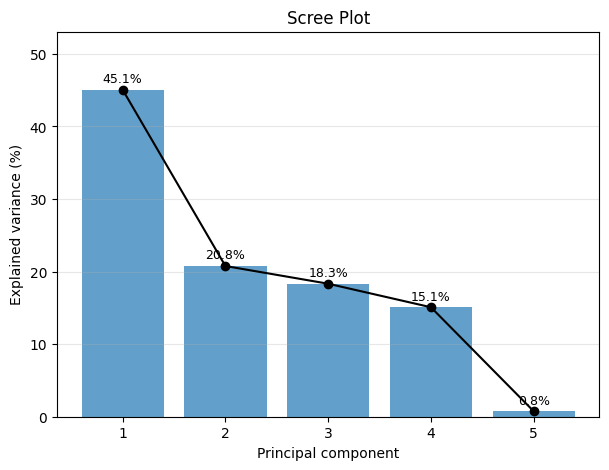

In [15]:
explained_var = pca.explained_variance_ratio_ * 100
components = range(1, len(explained_var) + 1)

plt.figure(figsize=(7, 5))

plt.bar(components, explained_var, alpha=0.7)
plt.plot(components, explained_var, marker="o", color="black")

for x, y in zip(components, explained_var):
    plt.text(x, y + 1, f"{y:.1f}%", ha="center", fontsize=9)

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("Scree Plot")
plt.xticks(components)
plt.ylim(0, max(explained_var) + 8)
plt.grid(axis="y", alpha=0.3)

plt.savefig(FIG_DIR / "pca_scree_plot.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "pca_scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

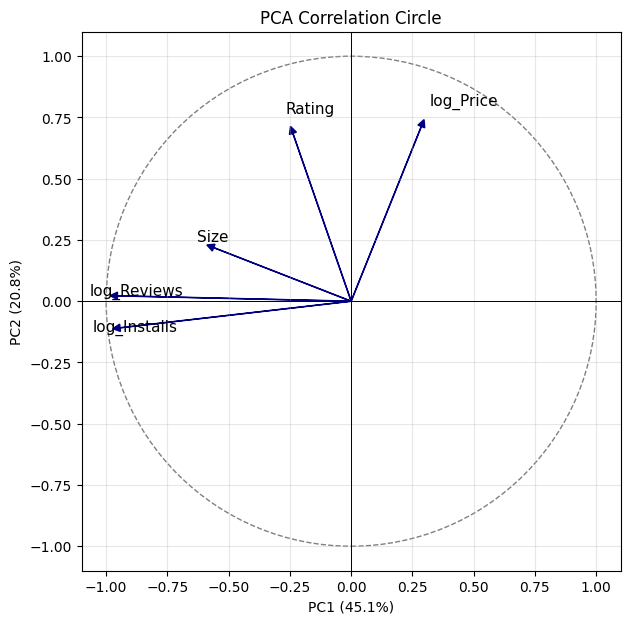

In [14]:
features = pca_data.columns

# Correlations between original variables and PCs
loadings_corr = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(7, 7))

# Unit circle
circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
plt.gca().add_artist(circle)

# Arrows for variables
for i, feature in enumerate(features):
    plt.arrow(
        0, 0,
        loadings_corr[i, 0],
        loadings_corr[i, 1],
        head_width=0.03,
        head_length=0.03,
        color="navy"
    )
    plt.text(
        loadings_corr[i, 0] * 1.12,
        loadings_corr[i, 1] * 1.12,
        feature,
        fontsize=11
    )

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA Correlation Circle")

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "pca_correlation_circle.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "pca_correlation_circle.png", dpi=300, bbox_inches="tight")
plt.show()

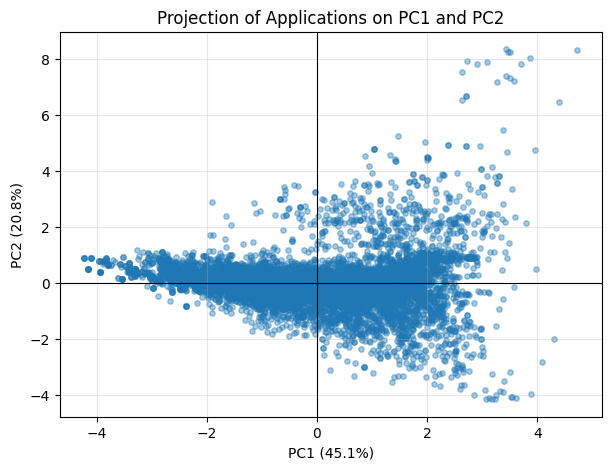

In [17]:
pca = PCA()
pca_scores = pca.fit_transform(pca_scaled)

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_scores[:, 0],
    pca_scores[:, 1],
    alpha=0.4,
    s=15
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("Projection of Applications on PC1 and PC2")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "pca_observations_projection.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "pca_observations_projection.png", dpi=300, bbox_inches="tight")
plt.show()

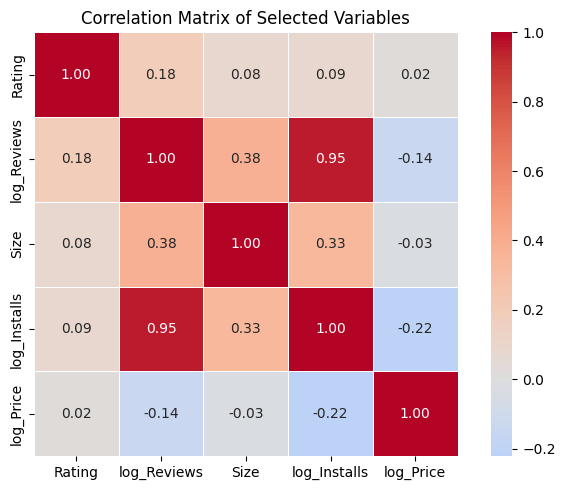

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_vars = ["Rating", "log_Reviews", "Size", "log_Installs", "log_Price"]
corr_matrix = data[corr_vars].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Selected Variables")
plt.tight_layout()

plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "correlation_heatmap.pdf", bbox_inches="tight")
plt.show()